# SMOTE-NC Comparison: Class-Weighting vs Synthetic Oversampling

UK RMBS loan-level data. Secondary/contextual content - tests whether SMOTE-NC oversampling improves LR/RF predictive performance over the class-weighting approach used in `ml_comparison_model.ipynb`. Does not touch RQ1 or the inferential baseline model.

SMOTE-NC (not vanilla SMOTE) is used because most predictors here are dummy-encoded categoricals; vanilla SMOTE's linear interpolation would produce nonsensical fractional dummy values (e.g. `PropType_Flat=0.5`). SMOTE-NC (Chawla et al., 2002 extension) handles categorical columns via majority-vote among neighbors instead of interpolation.

**Literature context:** van den Goorbergh et al. (2022, *J Clin Epidemiol*) found SMOTE/class-balancing techniques did not improve AUC over class-weighting on comparable rare-event prediction tasks, and worsened calibration - this script tests that finding empirically on this data rather than assuming it holds.

## Setup

In [1]:
# pip install imbalanced-learn - not preinstalled in Colab by default
!pip install -q imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    classification_report, confusion_matrix,
)
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline  # NOT sklearn's Pipeline -
                                                          # resamples inside each CV fold


def youdens_j_threshold(y_true, y_pred_prob):
    """Threshold maximising Youden's J = TPR - FPR (Youden, 1950) - same
    quantity as the KS statistic used for cutoffs in credit scoring
    (Hand & Henley, 1997). Mirrors the threshold logic already used in
    the inference and ML-comparison scripts for consistency."""
    fpr, tpr, thresh = roc_curve(y_true, y_pred_prob)
    return thresh[np.argmax(tpr - fpr)]


from google.colab import drive
drive.mount("/content/drive")

DATA_FOLDER = "/content/drive/MyDrive/Dissertation/data"
RANDOM_STATE = 42

Mounted at /content/drive


In [2]:
# Okabe-Ito palette, continued from the other scripts
PALETTE = {
    "primary": "#0072B2", "highlight": "#D55E00", "secondary": "#009E73",
    "tertiary": "#E69F00", "neutral": "#3A3A3A",
}
plt.rcParams.update({
    "axes.edgecolor": PALETTE["neutral"], "axes.labelcolor": PALETTE["neutral"],
    "xtick.color": PALETTE["neutral"], "ytick.color": PALETTE["neutral"],
    "text.color": PALETTE["neutral"], "axes.grid": True,
    "grid.color": "#D9D9D9", "grid.linewidth": 0.5, "figure.dpi": 110,
})
FIGURE_COUNTER = {"n": 22}  # continues from the ML-comparison script's Figure 22


def styled_figure(title, xlabel, ylabel):
    FIGURE_COUNTER["n"] += 1
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_title(f"Figure {FIGURE_COUNTER['n']}: {title}",
                 fontsize=11, fontweight="bold", color=PALETTE["neutral"], pad=12)
    ax.set_xlabel(xlabel, fontsize=9.5)
    ax.set_ylabel(ylabel, fontsize=9.5)
    return fig, ax

## Step 1: Load Data

Same predictor set as `ml_comparison_model.ipynb`, for direct comparability.

In [3]:
df = pd.read_csv(f"{DATA_FOLDER}/cleaned_dissertation_data.csv", low_memory=False)
print(f"Loaded: {len(df):,} rows, {df.shape[1]} cols, "
      f"default rate = {df['default'].mean():.2%}")

predictors = [
    "Original_LTV", "Interest_Rate", "Loan_Term", "Income_log",
    "PropType_Flat", "PropType_Bungalow", "PropType_Terraced",
    "Purpose_Remortgage", "Purpose_DebtConsolidation", "Purpose_Renovation",
    "Purpose_RemortgageEquityRelease", "Purpose_Other", "IncVerif_Other",
]
X = df[predictors].astype(float)
y = df["default"].astype(int)

# indices 0-3 are continuous (Original_LTV, Interest_Rate, Loan_Term,
# Income_log); everything from index 4 onward is a 0/1 dummy - tell
# SMOTENC which columns to treat as categorical
categorical_idx = list(range(4, len(predictors)))
print(f"Categorical column indices for SMOTE-NC: {categorical_idx} "
      f"({[predictors[i] for i in categorical_idx]})")

Loaded: 163,348 rows, 61 cols, default rate = 1.05%
Categorical column indices for SMOTE-NC: [4, 5, 6, 7, 8, 9, 10, 11, 12] (['PropType_Flat', 'PropType_Bungalow', 'PropType_Terraced', 'Purpose_Remortgage', 'Purpose_DebtConsolidation', 'Purpose_Renovation', 'Purpose_RemortgageEquityRelease', 'Purpose_Other', 'IncVerif_Other'])


## Step 2: Train/Test Split and Reproducibility Check

80/20 stratified split, identical parameters to `ml_comparison_model.ipynb`. The index hash below confirms both scripts evaluate on the same held-out rows - required for the comparison in Step 6 to be valid.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows, {y_train.sum():,} events "
      f"({y_train.mean():.2%})")
print(f"Test: {len(X_test):,} rows, {y_test.sum():,} events "
      f"({y_test.mean():.2%}) - held out untouched, never resampled")

test_index_hash = hashlib.md5(
    ",".join(map(str, sorted(X_test.index))).encode()
).hexdigest()
print(f"Test-set index hash: {test_index_hash}")
print("Compare this against the same check run in ml_comparison_model.ipynb - "
      "matching hashes confirm both scripts evaluated on the same held-out rows.")

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 130,678 rows, 1,377 events (1.05%)
Test: 32,670 rows, 344 events (1.05%) - held out untouched, never resampled
Test-set index hash: e3895d473eed1bf075aca9aaba705456
Compare this against the same check run in ml_comparison_model.ipynb - matching hashes confirm both scripts evaluated on the same held-out rows.


## Step 3a: Tune Logistic Regression with SMOTE-NC

Scaler runs **before** SMOTE in the pipeline - SMOTENC's neighbour search is distance-based, and unscaled continuous predictors with very different ranges (e.g. `Loan_Term` ~26-599 vs `Interest_Rate` ~0-8) would otherwise dominate the distance metric, distorting which synthetic examples get generated. Scaling all columns (including the 0/1 dummies) is harmless for SMOTENC's categorical handling, which matches on equality rather than distance for those columns regardless of their numeric labels.

`sampling_strategy="auto"` balances minority:majority to 1:1 within each fold's training partition - the standard default for this kind of comparison (matches van den Goorbergh et al.'s setup).

In [5]:
lr_smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTENC(categorical_features=categorical_idx,
                       sampling_strategy="auto", random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs")),  # no class_weight -
                                                                    # SMOTE handles balance
])
lr_smote_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}
lr_smote_search = GridSearchCV(
    lr_smote_pipeline, lr_smote_grid, cv=inner_cv, scoring="average_precision", n_jobs=-1
)
lr_smote_search.fit(X_train, y_train)
print(f"Best SMOTE-NC LR: C={lr_smote_search.best_params_['clf__C']}, "
      f"CV PR-AUC={lr_smote_search.best_score_:.4f}")

Best SMOTE-NC LR: C=0.001, CV PR-AUC=0.0198


## Step 3b: Tune Random Forest with SMOTE-NC

Same scaler-before-SMOTE ordering and grid as `ml_comparison_model.ipynb`'s Random Forest step, for a like-for-like comparison.

In [6]:
rf_smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTENC(categorical_features=categorical_idx,
                       sampling_strategy="auto", random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),  # no
                                                            # class_weight, same reason
])
rf_smote_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [5, 10, 20],
    "clf__min_samples_leaf": [5, 20, 50],
}
rf_smote_search = GridSearchCV(
    rf_smote_pipeline, rf_smote_grid, n_jobs=-1, cv=inner_cv,
    scoring="average_precision",
)
rf_smote_search.fit(X_train, y_train)
print(f"Best SMOTE-NC RF: {rf_smote_search.best_params_}, "
      f"CV PR-AUC={rf_smote_search.best_score_:.4f}")

smote_models = {
    "Logistic Regression (SMOTE-NC)": lr_smote_search.best_estimator_,
    "Random Forest (SMOTE-NC)": rf_smote_search.best_estimator_,
}

Best SMOTE-NC RF: {'clf__max_depth': 5, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 100}, CV PR-AUC=0.0214


## Step 4: Test-Set Evaluation

Single evaluation on the held-out test set, touched once per model, using each model's tuned SMOTE-NC pipeline.

In [7]:
smote_results = {}
for name, model in smote_models.items():
    test_pred = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, test_pred)
    pr_auc = average_precision_score(y_test, test_pred)
    smote_results[name] = {"pred": test_pred, "roc_auc": roc_auc, "pr_auc": pr_auc}
    print(f"{name}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

Logistic Regression (SMOTE-NC): ROC-AUC=0.6839, PR-AUC=0.0206
Random Forest (SMOTE-NC): ROC-AUC=0.7041, PR-AUC=0.0228


## Step 5: Classification Reports (Precision/Recall/F1 per Class)

Mirrors `ml_comparison_model.ipynb`'s equivalent step, so both comparisons report the same operating-threshold detail, not just AUC summary stats. Threshold selection stays leakage-safe: Youden's J threshold is derived from each model's training-set out-of-fold predictions (`cross_val_predict`, same `inner_cv` used for hyperparameter tuning), never from the test set directly. `cross_val_predict` refits the full pipeline (scaler + SMOTENC + classifier) fresh on each fold's training partition, so the resampling step is correctly re-run inside each fold here too, not just during tuning.

In [8]:
for name, model in smote_models.items():
    oof_pred = cross_val_predict(
        model, X_train, y_train, cv=inner_cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    threshold = youdens_j_threshold(y_train, oof_pred)
    test_pred_class = (smote_results[name]["pred"] >= threshold).astype(int)
    print(f"\n{name} (threshold={threshold:.4f}):")
    print(classification_report(y_test, test_pred_class,
                                 target_names=["No Default", "Default"], digits=4))
    cm = confusion_matrix(y_test, test_pred_class, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm, index=["Actual: No Default", "Actual: Default"],
        columns=["Predicted: No Default", "Predicted: Default"]
    )
    print(f"Confusion matrix ({name}, test set, n={len(y_test):,}):")
    print(cm_df)


Logistic Regression (SMOTE-NC) (threshold=0.4514):
              precision    recall  f1-score   support

  No Default     0.9958    0.4889    0.6558     32326
     Default     0.0165    0.8052    0.0323       344

    accuracy                         0.4923     32670
   macro avg     0.5061    0.6471    0.3441     32670
weighted avg     0.9855    0.4923    0.6493     32670

Confusion matrix (Logistic Regression (SMOTE-NC), test set, n=32,670):
                    Predicted: No Default  Predicted: Default
Actual: No Default                  15805               16521
Actual: Default                        67                 277

Random Forest (SMOTE-NC) (threshold=0.4726):
              precision    recall  f1-score   support

  No Default     0.9958    0.4962    0.6623     32326
     Default     0.0167    0.8023    0.0326       344

    accuracy                         0.4994     32670
   macro avg     0.5062    0.6492    0.3475     32670
weighted avg     0.9855    0.4994    0.6557   

## Step 6: Class-Weighting vs SMOTE-NC Comparison

Loaded from `ml_comparison_model.ipynb`'s saved output, not hardcoded, so this stays correct if that script is ever re-run.

In [9]:
weighted_summary = pd.read_csv(f"{DATA_FOLDER}/model_comparison_summary.csv", index_col=0)
comparison = pd.DataFrame({
    "LR (class-weighted)": weighted_summary.loc["Logistic Regression"],
    "LR (SMOTE-NC)": pd.Series(smote_results["Logistic Regression (SMOTE-NC)"]).loc[["roc_auc", "pr_auc"]].rename({"roc_auc": "ROC-AUC", "pr_auc": "PR-AUC"}),
    "RF (class-weighted)": weighted_summary.loc["Random Forest"],
    "RF (SMOTE-NC)": pd.Series(smote_results["Random Forest (SMOTE-NC)"]).loc[["roc_auc", "pr_auc"]].rename({"roc_auc": "ROC-AUC", "pr_auc": "PR-AUC"}),
}).round(4)
print("Class-weighting vs SMOTE-NC comparison:")
print(comparison)

Class-weighting vs SMOTE-NC comparison:
         LR (class-weighted) LR (SMOTE-NC)  RF (class-weighted) RF (SMOTE-NC)
ROC-AUC               0.7179      0.683894               0.7152      0.704067
PR-AUC                0.0280      0.020608               0.0259      0.022769


## Step 7: Calibration Comparison

Tests the specific literature claim (van den Goorbergh et al., 2022) that class-balancing techniques worsen calibration. Compare against the class-weighted calibration figure in `ml_comparison_model.ipynb`.

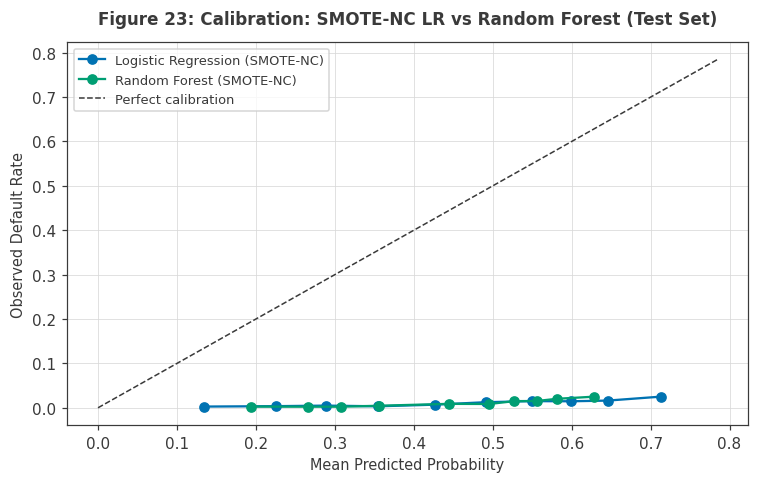

In [10]:
fig, ax = styled_figure(
    "Calibration: SMOTE-NC LR vs Random Forest (Test Set)",
    "Mean Predicted Probability", "Observed Default Rate"
)
colors_smote = {"Logistic Regression (SMOTE-NC)": PALETTE["primary"],
                 "Random Forest (SMOTE-NC)": PALETTE["secondary"]}
max_val = 0
for name, res in smote_results.items():
    calib_df = pd.DataFrame({"pred": res["pred"], "obs": y_test.values})
    calib_df["decile"] = pd.qcut(calib_df["pred"], q=10, duplicates="drop")
    calib = calib_df.groupby("decile", observed=True).agg(
        mean_pred=("pred", "mean"), mean_obs=("obs", "mean")
    )
    max_val = max(max_val, calib["mean_pred"].max(), calib["mean_obs"].max())
    ax.plot(calib["mean_pred"], calib["mean_obs"], marker="o",
            color=colors_smote[name], label=name)
ax.plot([0, max_val * 1.1], [0, max_val * 1.1], color=PALETTE["neutral"],
        linestyle="--", linewidth=1, label="Perfect calibration")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_smote_calibration.png",
            bbox_inches="tight")
plt.show()

## Export Result Table

In [11]:
comparison.to_csv(f"{DATA_FOLDER}/smote_vs_weighted_comparison.csv")
print(f"Saved comparison table to {DATA_FOLDER}/smote_vs_weighted_comparison.csv")

Saved comparison table to /content/drive/MyDrive/Dissertation/data/smote_vs_weighted_comparison.csv
